# Visualising the Nest Forcing Ramp

When an FVCOM model is started from rest, applying full boundary forcing immediately can cause a numerical shock. `NestManager.apply_ramp()` addresses this by smoothly blending each forcing variable from a calm initial state up to its full value. Three ramp shapes are available via the `ramp_type` argument:

| `ramp_type` | Formula | Smoothness | Reaches full amplitude |
|---|---|---|---|
| `'cosine'` **(default)** | $\frac{1}{2}\!\left(1 - \cos\!\left(\frac{\pi t}{T}\right)\right)$ | $C^1$ at both ends | Exactly at $t = T$ |
| `'tanh'` | $\tanh\!\left(\frac{t}{T}\right)$ | $C^\infty$ everywhere | Asymptotic (~76 % at $t=T$, ~99.5 % at $t=3T$) |
| `'linear'` | $\min\!\left(\frac{t}{T},\,1\right)$ | $C^0$ (kinked) | Exactly at $t = T$ |

For all types, the forcing at each time step is:

$$f_{\text{ramped}}(t) = f_0 \,(1 - \text{ramp}(t)) + f(t)\,\text{ramp}(t)$$

where $f_0$ is the initial value (zero for velocities and zeta; user-supplied for temperature and salinity).

This notebook demonstrates the effect of `apply_ramp()` on synthetic forcing data, without requiring real CMEMS or grid files.

## 1. Imports

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta

# Suppress a NumPy 2.4 deprecation warning that arises when loading .npy files
# saved with older NumPy versions (align stored as int 0 rather than bool).
warnings.filterwarnings(
    'ignore',
    message=r'dtype\(\): align should be passed as Python or NumPy boolean',
    category=np.exceptions.VisibleDeprecationWarning,
)

## 2. Ramp Shape

The three ramp types have different smoothness and endpoint properties. The left panel compares all three at the same `ramp_length` (T = 24 h). The right panel shows the cosine default at several timescales.

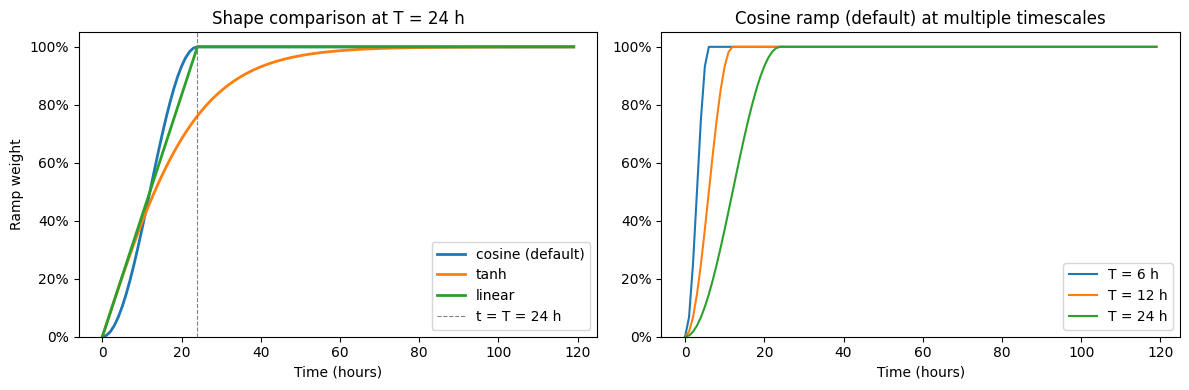

In [2]:
# Simulation period: 5 days at hourly resolution
start = datetime(2025, 6, 14)
n_hours = 5 * 24
dates = [start + timedelta(hours=h) for h in range(n_hours)]
t_sec = np.array([(d - dates[0]).total_seconds() for d in dates])
t_hours = t_sec / 3600

T_sec = 24 * 3600   # ramp_length for the shape comparison
ramp_cosine = np.where(t_sec >= T_sec, 1.0, 0.5 * (1 - np.cos(np.pi * t_sec / T_sec)))
ramp_tanh   = np.tanh(t_sec / T_sec)
ramp_linear = np.minimum(t_sec / T_sec, 1.0)

ramp_lengths_hours = [6, 12, 24]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: shape comparison at T = 24 h
axes[0].plot(t_hours, ramp_cosine, label='cosine (default)', color='tab:blue',   lw=2)
axes[0].plot(t_hours, ramp_tanh,   label='tanh',             color='tab:orange', lw=2)
axes[0].plot(t_hours, ramp_linear, label='linear',           color='tab:green',  lw=2)
axes[0].axvline(24, color='grey', lw=0.8, ls='--', label='t = T = 24 h')
axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Ramp weight')
axes[0].set_title('Shape comparison at T = 24 h')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# Right: cosine (default) at multiple timescales
for T_h in ramp_lengths_hours:
    T_s = T_h * 3600
    ramp_c = np.where(t_sec >= T_s, 1.0, 0.5 * (1 - np.cos(np.pi * t_sec / T_s)))
    axes[1].plot(t_hours, ramp_c, label=f'T = {T_h} h')
axes[1].set_xlabel('Time (hours)')
axes[1].set_title('Cosine ramp (default) at multiple timescales')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

fig.tight_layout()
plt.show()

## 3. Synthetic Forcing Data

We generate simple synthetic time series to stand in for real forcing variables across a small number of points. The forcing is kept deliberately simple so the effect of the ramp is obvious:

| Variable | Shape | Synthetic signal |
|---|---|---|
| `zeta` | (time, nodes) | constant + small diurnal oscillation |
| `u`, `v` | (time, depth, elements) | depth-varying sinusoid |
| `temp` | (time, depth, nodes) | realistic stratified profile |
| `salinity` | (time, depth, nodes) | realistic stratified profile |

In [3]:
rng = np.random.default_rng(42)

n_times    = n_hours
n_nodes    = 20
n_elements = 12
n_sigma    = 10   # sigma layers

# --- zeta: constant offset + diurnal tide, shape (time, nodes) ---
omega_M2 = 2 * np.pi / (12.42 * 3600)   # M2 tidal frequency
zeta_amp  = 1.5 + 0.5 * rng.random(n_nodes)   # node-varying amplitude (m)
zeta = (zeta_amp[np.newaxis, :]
        * np.sin(omega_M2 * t_sec[:, np.newaxis]))

# --- u, v: depth-varying velocity, shape (time, sigma, elements) ---
depth_profile = np.linspace(1.0, 0.3, n_sigma)   # surface→bed shear
u_amp = 0.3 + 0.1 * rng.random(n_elements)
v_amp = 0.2 + 0.1 * rng.random(n_elements)
u = (u_amp[np.newaxis, np.newaxis, :]
     * depth_profile[np.newaxis, :, np.newaxis]
     * np.sin(omega_M2 * t_sec[:, np.newaxis, np.newaxis]))
v = (v_amp[np.newaxis, np.newaxis, :]
     * depth_profile[np.newaxis, :, np.newaxis]
     * np.cos(omega_M2 * t_sec[:, np.newaxis, np.newaxis]))

# --- temp: stratified profile, shape (time, sigma, nodes) ---
temp_surface = 15.0 + 0.5 * rng.random(n_nodes)
temp_bottom  =  9.0 + 0.2 * rng.random(n_nodes)
temp_profile = np.linspace(0, 1, n_sigma)[:, np.newaxis]   # 0=surface, 1=bottom
temp = (temp_surface[np.newaxis, np.newaxis, :]
        + temp_profile[np.newaxis, :, :]
        * (temp_bottom - temp_surface)[np.newaxis, np.newaxis, :])
temp = np.broadcast_to(temp, (n_times, n_sigma, n_nodes)).copy()

# --- salinity: stratified profile, shape (time, sigma, nodes) ---
sal_surface = 32.0 + 0.3 * rng.random(n_nodes)
sal_bottom  = 35.0 + 0.1 * rng.random(n_nodes)
salinity = (sal_surface[np.newaxis, np.newaxis, :]
            + temp_profile[np.newaxis, :, :]
            * (sal_bottom - sal_surface)[np.newaxis, np.newaxis, :])
salinity = np.broadcast_to(salinity, (n_times, n_sigma, n_nodes)).copy()

print('Synthetic data shapes:')
for name, arr in [('zeta', zeta), ('u', u), ('v', v),
                  ('temp', temp), ('salinity', salinity)]:
    print(f'  {name:10s}: {arr.shape}')

Synthetic data shapes:
  zeta      : (120, 20)
  u         : (120, 10, 12)
  v         : (120, 10, 12)
  temp      : (120, 10, 20)
  salinity  : (120, 10, 20)


## 4. Apply the Ramp

We replicate what `NestManager.apply_ramp()` does internally, calling `NestManager._build_ramp` and `NestManager._apply_ramp_to_array` directly. We generate four variants — all three types at T = 24 h, plus the default cosine at T = 6 h — to compare their effect on the forcing variables.

In [4]:
from pyfvcom2.nest import NestManager

def apply_ramp_to_data(forcing, ramp_length_sec, t_sec, ramp_type='cosine', initial_ts=None):
    """Apply a ramp to a dict of forcing arrays.

    Returns a new dict of ramped copies; the originals are unchanged.
    """
    ramp = NestManager._build_ramp(t_sec, ramp_length_sec, ramp_type)
    result = {}
    for var, data in forcing.items():
        if var in ('u', 'v', 'zeta'):
            init = 0.0
        elif var == 'temp' and initial_ts is not None:
            init = initial_ts[0]
        elif var == 'salinity' and initial_ts is not None:
            init = initial_ts[1]
        else:
            result[var] = data.copy()
            continue
        result[var] = NestManager._apply_ramp_to_array(data, ramp, init)
    return result

# Nominal initial T/S values (climatological or model background)
initial_ts = [10.0, 34.5]   # °C, PSU

forcing_raw = dict(zeta=zeta, u=u, v=v, temp=temp, salinity=salinity)

cosine_6h  = apply_ramp_to_data(forcing_raw,  6 * 3600, t_sec, ramp_type='cosine', initial_ts=initial_ts)
cosine_24h = apply_ramp_to_data(forcing_raw, 24 * 3600, t_sec, ramp_type='cosine', initial_ts=initial_ts)
tanh_24h   = apply_ramp_to_data(forcing_raw, 24 * 3600, t_sec, ramp_type='tanh',   initial_ts=initial_ts)
linear_24h = apply_ramp_to_data(forcing_raw, 24 * 3600, t_sec, ramp_type='linear', initial_ts=initial_ts)

print('Variants prepared: cosine T=6h, cosine T=24h, tanh T=24h, linear T=24h')

Variants prepared: cosine T=6h, cosine T=24h, tanh T=24h, linear T=24h


## 5. Visualisation

### 5a. Sea Surface Elevation (zeta) at a single node

All four variants are shown together, making it easy to compare the ramp shapes and timescales. Note that for `tanh` at T = 24 h the forcing has only reached ~76 % at t = 24 h, whereas both `cosine` and `linear` are at full amplitude by then.

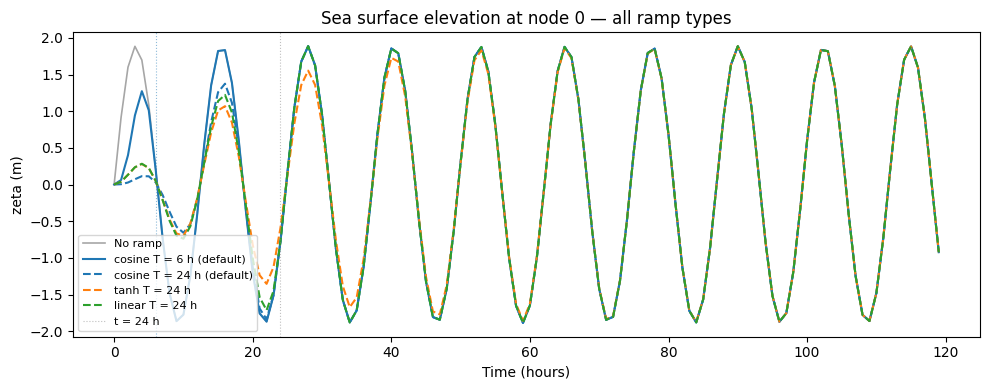

In [5]:
node_idx = 0   # representative node

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hours, forcing_raw['zeta'][:, node_idx],
        color='black', lw=1.2, label='No ramp', alpha=0.35)
ax.plot(t_hours, cosine_6h['zeta'][:, node_idx],
        color='tab:blue', lw=1.5, ls='-',  label='cosine T = 6 h (default)')
ax.plot(t_hours, cosine_24h['zeta'][:, node_idx],
        color='tab:blue', lw=1.5, ls='--', label='cosine T = 24 h (default)')
ax.plot(t_hours, tanh_24h['zeta'][:, node_idx],
        color='tab:orange', lw=1.5, ls='--', label='tanh T = 24 h')
ax.plot(t_hours, linear_24h['zeta'][:, node_idx],
        color='tab:green', lw=1.5, ls='--', label='linear T = 24 h')

ax.axvline( 6, color='tab:blue', lw=0.8, ls=':', alpha=0.5)
ax.axvline(24, color='grey',     lw=0.8, ls=':', alpha=0.5, label='t = 24 h')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('zeta (m)')
ax.set_title(f'Sea surface elevation at node {node_idx} — all ramp types')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 5b. Surface velocity (u) at a single element

The velocity is 3-D (time, sigma, element). Here we pick the surface layer.

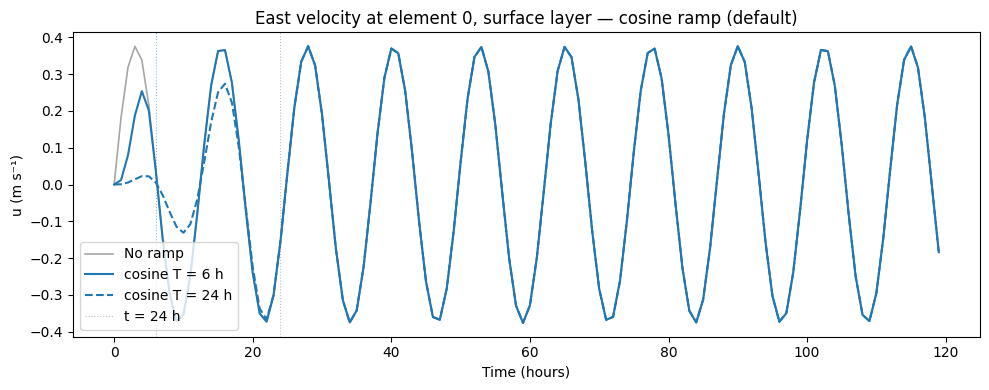

In [6]:
elem_idx   = 0   # representative element
sigma_surf = 0   # surface sigma layer

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hours, forcing_raw['u'][:, sigma_surf, elem_idx],
        color='black', lw=1.2, label='No ramp', alpha=0.35)
ax.plot(t_hours, cosine_6h['u'][:, sigma_surf, elem_idx],
        color='tab:blue', lw=1.5, ls='-',  label='cosine T = 6 h')
ax.plot(t_hours, cosine_24h['u'][:, sigma_surf, elem_idx],
        color='tab:blue', lw=1.5, ls='--', label='cosine T = 24 h')

ax.axvline( 6, color='tab:blue', lw=0.8, ls=':', alpha=0.5)
ax.axvline(24, color='grey',     lw=0.8, ls=':', alpha=0.5, label='t = 24 h')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('u (m s⁻¹)')
ax.set_title(f'East velocity at element {elem_idx}, surface layer — cosine ramp (default)')
ax.legend()
fig.tight_layout()
plt.show()

### 5c. Temperature ramp from an initial background value

Temperature (and salinity) are ramped from a user-supplied background state rather than from zero. Here we use an initial temperature of 10 °C and show the surface layer at one node.

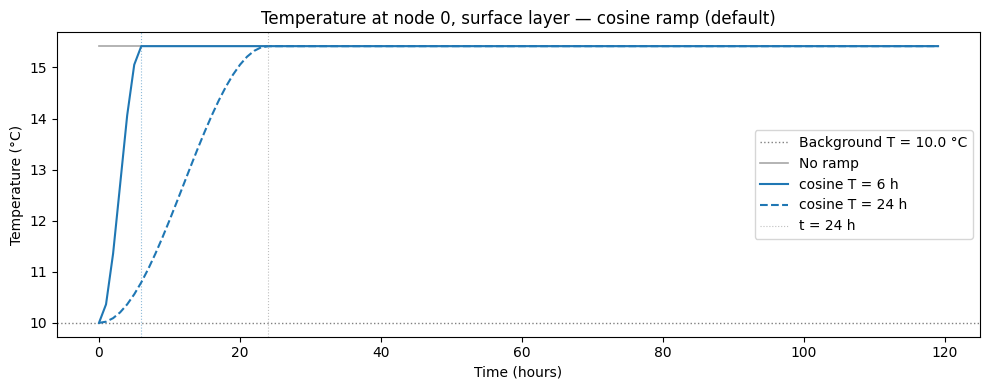

In [7]:
node_idx   = 0
sigma_surf = 0
T0_temp    = initial_ts[0]   # 10 °C background

fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(T0_temp, color='grey', lw=1.0, ls=':', label=f'Background T = {T0_temp} °C')
ax.plot(t_hours, forcing_raw['temp'][:, sigma_surf, node_idx],
        color='black', lw=1.2, label='No ramp', alpha=0.35)
ax.plot(t_hours, cosine_6h['temp'][:, sigma_surf, node_idx],
        color='tab:blue', lw=1.5, ls='-',  label='cosine T = 6 h')
ax.plot(t_hours, cosine_24h['temp'][:, sigma_surf, node_idx],
        color='tab:blue', lw=1.5, ls='--', label='cosine T = 24 h')

ax.axvline( 6, color='tab:blue', lw=0.8, ls=':', alpha=0.5)
ax.axvline(24, color='grey',     lw=0.8, ls=':', alpha=0.5, label='t = 24 h')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Temperature at node {node_idx}, surface layer — cosine ramp (default)')
ax.legend()
fig.tight_layout()
plt.show()

### 5d. Depth–time Hovmöller: velocity with and without ramp

This panel shows how the ramp suppresses velocity at all depths during spin-up, not just at the surface.

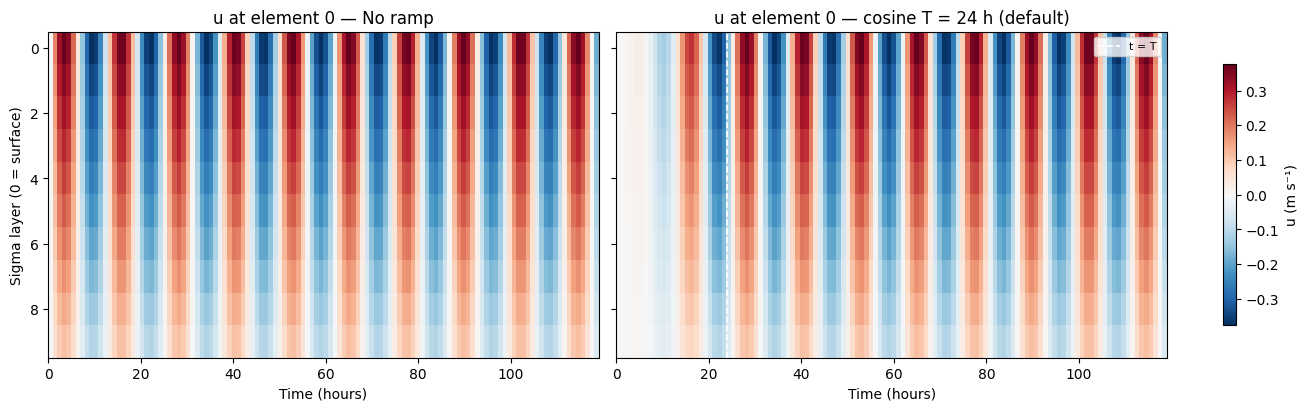

In [8]:
elem_idx = 0

u_raw_hov      = forcing_raw['u'][:, :, elem_idx].T   # (sigma, time)
u_cosine24_hov = cosine_24h['u'][:, :, elem_idx].T

vmax = np.abs(u_raw_hov).max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True,
                         constrained_layout=True)
kw = dict(aspect='auto', origin='upper',
          extent=[0, t_hours[-1], n_sigma - 0.5, -0.5],
          vmin=-vmax, vmax=vmax, cmap='RdBu_r')

im0 = axes[0].imshow(u_raw_hov,      **kw)
im1 = axes[1].imshow(u_cosine24_hov, **kw)

for ax, title in zip(axes, ['No ramp', 'cosine T = 24 h (default)']):
    ax.set_xlabel('Time (hours)')
    ax.set_title(f'u at element {elem_idx} — {title}')

axes[0].set_ylabel('Sigma layer (0 = surface)')
axes[1].axvline(24, color='white', lw=1.2, ls='--', label='t = T')
axes[1].legend(loc='upper right', fontsize=8)

fig.colorbar(im0, ax=axes, label='u (m s⁻¹)', shrink=0.8)
plt.show()

## 6. Summary

`NestManager.apply_ramp()` supports three ramp shapes via the `ramp_type` argument:

| `ramp_type` | Smoothness | Reaches full amplitude | Best suited for |
|---|---|---|---|
| `'cosine'` **(default)** | $C^1$ at both ends | Exactly at $t = T$ | Most cases — smooth, intuitive duration |
| `'tanh'` | $C^\infty$ everywhere | Asymptotic | Very energetic boundaries where maximum smoothness is needed |
| `'linear'` | $C^0$ (kinked at $t=0$ and $t=T$) | Exactly at $t = T$ | Mild boundaries where simplicity is preferred |

Key points:

- **Velocities and zeta** always start from zero and grow towards the full forcing value.
- **Temperature and salinity** start from a user-supplied background value (e.g. a model restart or climatological mean) and relax to the boundary forcing.
- For `'cosine'` and `'linear'`, `ramp_length` means the spin-up is *complete* at $t = T$. For `'tanh'`, it is a timescale: the spin-up is effectively complete at $t \approx 3T$.
- A shorter `ramp_length` produces a steeper spin-up; a longer one is smoother but delays the model reaching full forcing.

A typical choice is `ramp_length` between 6 and 24 hours for an hourly-forced coastal model, depending on how energetic the open boundary is.